# Earth2Studio: AI Weather Forecasting

This notebook demonstrates NVIDIA Earth2Studio for:
1. **2m Temperature** forecast (FCN)
2. **10m Wind Speed & MSLP** forecasts (SFNO)
3. **Hurricane Florence track comparison** (AIFS vs FCN vs ERA5 reanalysis)
4. **14-day extended range forecast** — Aurora Z500 animated GIF (Jan 2025 polar vortex)

### Prerequisites
- Python 3.12 with the `earth2` kernel
- `uv sync` (resolves all Earth2Studio extras)
- NVIDIA GPU with CUDA

---
## Imports & Config

In [3]:
import io
import os
from pathlib import Path
from datetime import datetime, timedelta

import imageio
import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import Image as IPImage
from tqdm import tqdm

os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"

import earth2studio.run as run
from earth2studio.models.px import AIFS, Aurora, FCN, SFNO
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import GFS, CDS, WB2ERA5, NCAR_ERA5, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_DIR = Path("/home/jovyan/Earth2")
os.chdir(PROJECT_DIR)

os.makedirs(PROJECT_DIR / "aifs_outputs", exist_ok=True)
os.makedirs(PROJECT_DIR / "aurora_outputs", exist_ok=True)

print(f"Device: {DEVICE}")

Device: cuda

In [3]:
import io
import os
from pathlib import Path
from datetime import datetime, timedelta

import imageio
import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import Image as IPImage
from tqdm import tqdm

os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"

import earth2studio.run as run
from earth2studio.models.px import AIFS, Aurora, FCN, SFNO
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import GFS, CDS, WB2ERA5, NCAR_ERA5, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_DIR = Path("/home/jovyan/Earth2")
os.chdir(PROJECT_DIR)

os.makedirs(PROJECT_DIR / "aifs_outputs", exist_ok=True)
os.makedirs(PROJECT_DIR / "aurora_outputs", exist_ok=True)

print(f"Device: {DEVICE}")

Device: cuda

## 2m Air Temperature Forecast

In [4]:
model = FCN.load_model(FCN.load_default_package())
data = GFS()

t2m_path = PROJECT_DIR/"t2m_outputs/fcn_gfs_forecast.zarr"
backend = ZarrBackend(str(t2m_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-08"], 10, model, data, backend)
print(backend.root.tree())

del model
torch.cuda.empty_cache()

2026-05-26 00:09:05.816 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-26 00:09:05.817 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-26 00:09:06.372 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 393209495-967460
2026-05-26 00:09:06.391 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 200278084-732664
2026-05-26 00:09:06.407 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 253104168-716388
2026-05-26 00:09:06.423 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 330543720-841319
2026-05-26 00:09:06.439 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 199554862-723222
2026-05-26 00:09:06.455 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-26 00:09:06.581 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 400526668-837990
2026-05-26 00:09:06.597 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 458275515-977912
2026-05-26 00:09:06.613 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 337303134-947326
2026-05-26 00:09:06.629 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 409106778-875921
2026-05-26 00:09:06.645 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 414147575-944928
2026-05-26 00:09:06.661 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:00<00:00, 62.12it/s]

2026-05-26 00:09:06.875 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-05-26 00:09:06.925 | INFO     | earth2studio.run:deterministic:139 - Inference starting!

Running inference: 100%|██████████| 11/11 [00:10<00:00,  1.06it/s]

2026-05-26 00:09:17.293 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (720,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 720, 1440) float32
├── r500 (1, 11, 720, 1440) float32
├── r850 (1, 11, 720, 1440) float32
├── sp (1, 11, 720, 1440) float32
├── t250 (1, 11, 720, 1440) float32
├── t2m (1, 11, 720, 1440) float32
├── t500 (1, 11, 720, 1440) float32
├── t850 (1, 11, 720, 1440) float32
├── tcwv (1, 11, 720, 1440) float32
├── time (1,) datetime64[ns]
├── u1000 (1, 11, 720, 1440) float32
├── u100m (1, 11, 720, 1440) float32
├── u10m (1, 11, 720, 1440) float32
├── u250 (1, 11, 720, 1440) float32
├── u500 (1, 11, 720, 1440) float32
├── u850 (1, 11, 720, 1440) float32
├── v1000 (1, 11, 720, 1440) float32
├── v100m (1, 11, 720, 1440) float32
├── v10m (1, 11, 720, 1440) float32
├── v250 (1, 11, 720, 1440) float32
├── v500 (1, 11, 720, 1440) float32
├── v850 (1, 11, 720, 1440) float32
├── z1000 (1, 11, 720, 1440) float32


In [4]:
model = FCN.load_model(FCN.load_default_package())
data = GFS()

t2m_path = PROJECT_DIR/"t2m_outputs/fcn_gfs_forecast.zarr"
backend = ZarrBackend(str(t2m_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-08"], 10, model, data, backend)
print(backend.root.tree())

del model
torch.cuda.empty_cache()

2026-05-26 00:09:05.816 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-26 00:09:05.817 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-26 00:09:06.372 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 393209495-967460
2026-05-26 00:09:06.391 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 200278084-732664
2026-05-26 00:09:06.407 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 253104168-716388
2026-05-26 00:09:06.423 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 330543720-841319
2026-05-26 00:09:06.439 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 199554862-723222
2026-05-26 00:09:06.455 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-26 00:09:06.581 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 400526668-837990
2026-05-26 00:09:06.597 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 458275515-977912
2026-05-26 00:09:06.613 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 337303134-947326
2026-05-26 00:09:06.629 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 409106778-875921
2026-05-26 00:09:06.645 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 414147575-944928
2026-05-26 00:09:06.661 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:00<00:00, 62.12it/s]

2026-05-26 00:09:06.875 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-05-26 00:09:06.925 | INFO     | earth2studio.run:deterministic:139 - Inference starting!

Running inference: 100%|██████████| 11/11 [00:10<00:00,  1.06it/s]

2026-05-26 00:09:17.293 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (720,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 720, 1440) float32
├── r500 (1, 11, 720, 1440) float32
├── r850 (1, 11, 720, 1440) float32
├── sp (1, 11, 720, 1440) float32
├── t250 (1, 11, 720, 1440) float32
├── t2m (1, 11, 720, 1440) float32
├── t500 (1, 11, 720, 1440) float32
├── t850 (1, 11, 720, 1440) float32
├── tcwv (1, 11, 720, 1440) float32
├── time (1,) datetime64[ns]
├── u1000 (1, 11, 720, 1440) float32
├── u100m (1, 11, 720, 1440) float32
├── u10m (1, 11, 720, 1440) float32
├── u250 (1, 11, 720, 1440) float32
├── u500 (1, 11, 720, 1440) float32
├── u850 (1, 11, 720, 1440) float32
├── v1000 (1, 11, 720, 1440) float32
├── v100m (1, 11, 720, 1440) float32
├── v10m (1, 11, 720, 1440) float32
├── v250 (1, 11, 720, 1440) float32
├── v500 (1, 11, 720, 1440) float32
├── v850 (1, 11, 720, 1440) float32
├── z1000 (1, 11, 720, 1440) float32


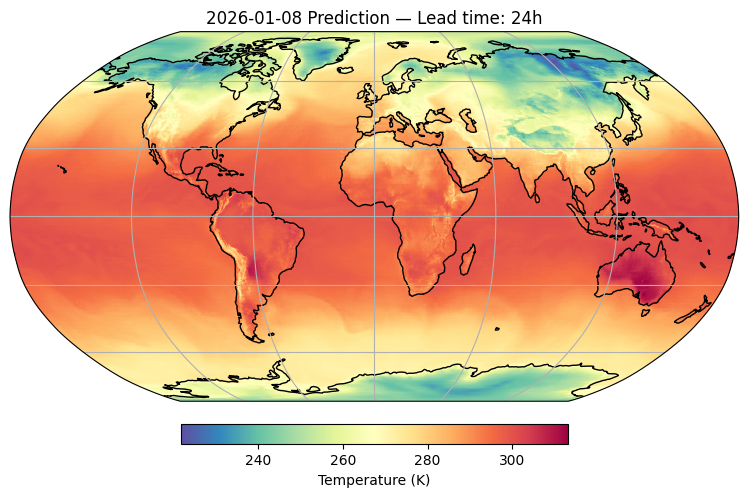

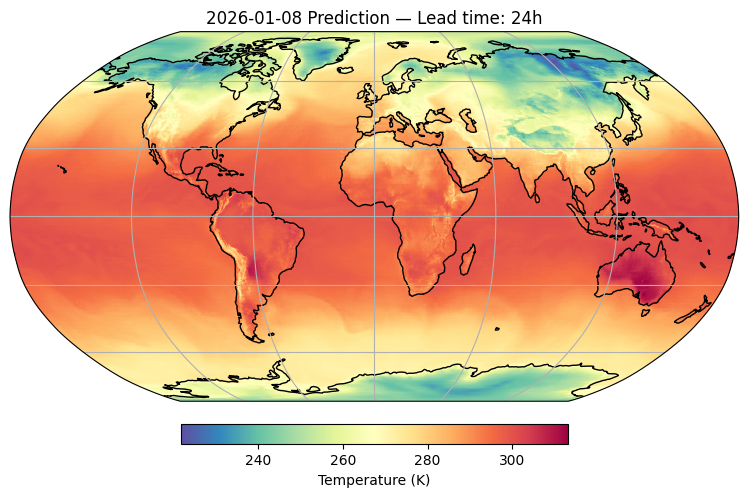

In [5]:
def plot_t2m(zarr_path, variable, step, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    projection = ccrs.Robinson()

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))
    im = ax.pcolormesh(
        ds["lon"], ds["lat"], ds[variable][0, step],
        transform=ccrs.PlateCarree(), cmap="Spectral_r",
    )
    plt.colorbar(
            im, 
            ax=ax, 
            orientation="horizontal", 
            pad=0.05, 
            label="Temperature (K)",
            shrink=0.5,  
            aspect=20
)

    ax.set_title(f"2026-01-08 Prediction — Lead time: {6 * step}h")
    ax.coastlines()
    ax.gridlines()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_t2m(t2m_path, "t2m", step=4, save_path=PROJECT_DIR / "t2m_outputs/t2m_prediction.jpg")

---
## 10m Wind Speed & MSLP Forecasts (SFNO)

In [13]:
sfno_model = SFNO.load_model(SFNO.load_default_package())
data = GFS()

sfno_path = PROJECT_DIR / "sfno_outputs/sfno_gfs_forecast.zarr"
sfno_path.parent.mkdir(parents=True, exist_ok=True)
backend = ZarrBackend(str(sfno_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-01"], 10, sfno_model, data, backend)
print(backend.root.tree())

del sfno_model
torch.cuda.empty_cache()

2026-05-26 00:10:29.041 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-26 00:10:29.042 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-05-26 00:10:29.440 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 210945366-591794
2026-05-26 00:10:29.456 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 180067903-910623
2026-05-26 00:10:29.473 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 258526459-815588
2026-05-26 00:10:29.490 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 367926743-957726
2026-05-26 00:10:29.506 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 205551634-750666
2026-05-26 00:10:29.523 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-05-26 00:10:29.654 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 397402082-1223716
2026-05-26 00:10:29.672 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 416783236-887721
2026-05-26 00:10:29.688 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 243920007-577907
2026-05-26 00:10:29.704 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 201208547-579837
2026-05-26 00:10:29.720 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 302363913-859119
2026-05-26 00:10:29.737 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

...

2026-05-26 00:10:30.297 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 366981432-945311
2026-05-26 00:10:30.313 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 287974570-901514
2026-05-26 00:10:30.329 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 174175517-762708
2026-05-26 00:10:30.346 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 215568560-734824
2026-05-26 00:10:30.362 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 361131975-856944
2026-05-26 00:10:30.378 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data: 100%|██████████| 73/73 [00:01<00:00, 61.06it/s]

2026-05-26 00:10:30.508 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 305163964-1255574
2026-05-26 00:10:30.524 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 200624858-583689
2026-05-26 00:10:30.540 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 157992006-816442
2026-05-26 00:10:30.556 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 343808409-947816
2026-05-26 00:10:30.572 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 195501052-756703
2026-05-26 00:10:30.587 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Running inference: 100%|██████████| 11/11 [00:31<00:00,  2.89s/it]

2026-05-26 00:11:02.782 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 721, 1440) float32
├── q100 (1, 11, 721, 1440) float32
├── q1000 (1, 11, 721, 1440) float32
├── q150 (1, 11, 721, 1440) float32
├── q200 (1, 11, 721, 1440) float32
├── q250 (1, 11, 721, 1440) float32
├── q300 (1, 11, 721, 1440) float32
├── q400 (1, 11, 721, 1440) float32
├── q50 (1, 11, 721, 1440) float32
├── q500 (1, 11, 721, 1440) float32
├── q600 (1, 11, 721, 1440) float32
├── q700 (1, 11, 721, 1440) float32
├── q850 (1, 11, 721, 1440) float32
├── q925 (1, 11, 721, 1440) float32
├── sp (1, 11, 721, 1440) float32
├── t100 (1, 11, 721, 1440) float32
├── t1000 (1, 11, 721, 1440) float32
├── t150 (1, 11, 721, 1440) float32
├── t200 (1, 11, 721, 1440) float32
├── t250 (1, 11, 721, 1440) float32
├── t2m (1, 11, 721, 1440) float32
├── t300 (1, 11, 721, 1440) float32
├── t400 (1, 11, 721, 1440) float

In [13]:
sfno_model = SFNO.load_model(SFNO.load_default_package())
data = GFS()

sfno_path = PROJECT_DIR / "sfno_outputs/sfno_gfs_forecast.zarr"
sfno_path.parent.mkdir(parents=True, exist_ok=True)
backend = ZarrBackend(str(sfno_path), backend_kwargs={"overwrite": True})

backend = run.deterministic(["2026-01-01"], 10, sfno_model, data, backend)
print(backend.root.tree())

del sfno_model
torch.cuda.empty_cache()

2026-05-26 00:10:29.041 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-26 00:10:29.042 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-05-26 00:10:29.440 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 210945366-591794
2026-05-26 00:10:29.456 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 180067903-910623
2026-05-26 00:10:29.473 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 258526459-815588
2026-05-26 00:10:29.490 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 367926743-957726
2026-05-26 00:10:29.506 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 205551634-750666
2026-05-26 00:10:29.523 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-05-26 00:10:29.654 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 397402082-1223716
2026-05-26 00:10:29.672 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 416783236-887721
2026-05-26 00:10:29.688 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 243920007-577907
2026-05-26 00:10:29.704 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 201208547-579837
2026-05-26 00:10:29.720 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 302363913-859119
2026-05-26 00:10:29.737 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

...

2026-05-26 00:10:30.297 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 366981432-945311
2026-05-26 00:10:30.313 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 287974570-901514
2026-05-26 00:10:30.329 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 174175517-762708
2026-05-26 00:10:30.346 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 215568560-734824
2026-05-26 00:10:30.362 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 361131975-856944
2026-05-26 00:10:30.378 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data: 100%|██████████| 73/73 [00:01<00:00, 61.06it/s]

2026-05-26 00:10:30.508 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 305163964-1255574
2026-05-26 00:10:30.524 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 200624858-583689
2026-05-26 00:10:30.540 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 157992006-816442
2026-05-26 00:10:30.556 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 343808409-947816
2026-05-26 00:10:30.572 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 195501052-756703
2026-05-26 00:10:30.587 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Running inference: 100%|██████████| 11/11 [00:31<00:00,  2.89s/it]

2026-05-26 00:11:02.782 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 721, 1440) float32
├── q100 (1, 11, 721, 1440) float32
├── q1000 (1, 11, 721, 1440) float32
├── q150 (1, 11, 721, 1440) float32
├── q200 (1, 11, 721, 1440) float32
├── q250 (1, 11, 721, 1440) float32
├── q300 (1, 11, 721, 1440) float32
├── q400 (1, 11, 721, 1440) float32
├── q50 (1, 11, 721, 1440) float32
├── q500 (1, 11, 721, 1440) float32
├── q600 (1, 11, 721, 1440) float32
├── q700 (1, 11, 721, 1440) float32
├── q850 (1, 11, 721, 1440) float32
├── q925 (1, 11, 721, 1440) float32
├── sp (1, 11, 721, 1440) float32
├── t100 (1, 11, 721, 1440) float32
├── t1000 (1, 11, 721, 1440) float32
├── t150 (1, 11, 721, 1440) float32
├── t200 (1, 11, 721, 1440) float32
├── t250 (1, 11, 721, 1440) float32
├── t2m (1, 11, 721, 1440) float32
├── t300 (1, 11, 721, 1440) float32
├── t400 (1, 11, 721, 1440) float

In [14]:
def plot_sfno_10m_wind(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    ws10 = np.sqrt(ds["u10m"][0, step] ** 2 + ds["v10m"][0, step] ** 2)
    projection = ccrs.Robinson()
    levels = np.arange(0, 40, 2)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], ws10, levels,
        transform=ccrs.PlateCarree(), cmap="YlOrRd", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="10 m Wind Speed (m/s)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — 10 m Wind Speed — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()


def plot_sfno_msl(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    msl_hpa = ds["msl"][0, step] / 100.0
    projection = ccrs.Robinson()
    levels = np.arange(960, 1045, 4)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], msl_hpa, levels,
        transform=ccrs.PlateCarree(), cmap="jet", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="Mean Sea Level Pressure (hPa)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — MSLP — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

In [12]:
# 10m wind speed
plot_sfno_10m_wind(sfno_path, step=4)
plot_sfno_10m_wind(sfno_path, step=8, extent=[220, 340, 20, 70])

NameError: name 'plot_sfno_10m_wind' is not defined

NameError: name 'plot_sfno_10m_wind' is not defined

In [6]:
# Mean sea level pressure
plot_sfno_msl(sfno_path, step=4)
plot_sfno_msl(sfno_path, step=8, extent=[220, 340, 20, 70])

NameError: name 'plot_sfno_msl' is not defined

NameError: name 'plot_sfno_msl' is not defined

## Hurricane Florence Track Comparison

Compare tropical cyclone tracks from AIFS (ECMWF), FCN (NVIDIA), and ERA5 reanalysis
for Hurricane Florence (September 2018).

In [7]:
FLORENCE_DIR = PROJECT_DIR / "florence_outputs"
FLORENCE_DIR.mkdir(exist_ok=True)

START_TIME = datetime(2018, 9, 13)
NSTEPS = 25
END_TIME = START_TIME + timedelta(hours=6 * NSTEPS)

### Inference helper

In [8]:
def run_tc_inference(prognostic, data_source, tracker, start_time, nsteps, save_path):
    """Run a prognostic model through the TC tracker and save the resulting tracks."""
    prognostic = prognostic.to(DEVICE)
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, _ = tracker(x, coords)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"Saved: {save_path}")
    return tracks

### 3a — AIFS (ECMWF)

In [9]:
aifs_model = AIFS.load_model(AIFS.load_default_package())
cds_data = CDS(cache=True)
tracker = TCTrackerWuDuan()

aifs_tracks = run_tc_inference(
    aifs_model, cds_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "aifs_paths.pt",
)

del aifs_model
torch.cuda.empty_cache()

2026-05-26 00:09:39.234 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2018-09-12 18:00:00 with 1 levels
2026-05-26 00:09:39.235 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2018-09-12 18:00:00 with 1 levels
2026-05-26 00:09:39.235 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2018-09-12 18:00:00 with 1 levels
2026-05-26 00:09:39.235 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_temperature at 2018-09-12 18:00:00 with 1 levels
2026-05-26 00:09:39.235 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2018-09-12 18:00:00 with 1 levels
2026-05-26 00:09:39.235 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: sp

 96%|█████████▌| 25/26 [00:21<00:00,  1.18it/s]

Saved: /home/jovyan/Earth2/florence_outputs/aifs_paths.pt

In [9]:
aifs_model = AIFS.load_model(AIFS.load_default_package())
cds_data = CDS(cache=True)
tracker = TCTrackerWuDuan()

aifs_tracks = run_tc_inference(
    aifs_model, cds_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "aifs_paths.pt",
)

del aifs_model
torch.cuda.empty_cache()

2026-05-26 00:09:39.234 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_u_component_of_wind at 2018-09-12 18:00:00 with 1 levels
2026-05-26 00:09:39.235 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 10m_v_component_of_wind at 2018-09-12 18:00:00 with 1 levels
2026-05-26 00:09:39.235 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_dewpoint_temperature at 2018-09-12 18:00:00 with 1 levels
2026-05-26 00:09:39.235 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: 2m_temperature at 2018-09-12 18:00:00 with 1 levels
2026-05-26 00:09:39.235 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: mean_sea_level_pressure at 2018-09-12 18:00:00 with 1 levels
2026-05-26 00:09:39.235 | INFO     | earth2studio.data.cds:_fetch_process:177 - Fetching CDS grib file for variable: sp

 96%|█████████▌| 25/26 [00:21<00:00,  1.18it/s]

Saved: /home/jovyan/Earth2/florence_outputs/aifs_paths.pt

### 3b — ERA5 Reanalysis (ground truth)

In [10]:
era5_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()
tracker.reset_path_buffer()

times = [START_TIME + timedelta(hours=6 * i) for i in range(NSTEPS + 1)]
for step, time in tqdm(enumerate(times), total=len(times)):
    da = era5_data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=DEVICE)
    output, _ = tracker(x, coords)

era5_tracks = output.cpu()
torch.save(era5_tracks, str(FLORENCE_DIR / "era5_paths.pt"))
print("Saved ERA5 tracks")

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 47.53it/s]

2026-05-26 00:10:05.791 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T00:00:00
2026-05-26 00:10:05.794 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-13T00:00:00
2026-05-26 00:10:05.796 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T00:00:00
2026-05-26 00:10:05.799 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T00:00:00
2026-05-26 00:10:05.801 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T00:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 52.42it/s]

2026-05-26 00:10:06.044 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T06:00:00
2026-05-26 00:10:06.046 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T06:00:00
2026-05-26 00:10:06.048 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-13T06:00:00
2026-05-26 00:10:06.051 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T06:00:00
2026-05-26 00:10:06.053 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T06:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 52.08it/s]

...

2026-05-26 00:10:10.797 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-18T18:00:00
2026-05-26 00:10:10.800 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-18T18:00:00
2026-05-26 00:10:10.802 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-18T18:00:00
2026-05-26 00:10:10.804 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-18T18:00:00
2026-05-26 00:10:10.806 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-18T18:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 52.80it/s]

2026-05-26 00:10:10.998 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T00:00:00
2026-05-26 00:10:11.000 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T00:00:00
2026-05-26 00:10:11.003 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-19T00:00:00
2026-05-26 00:10:11.005 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T00:00:00
2026-05-26 00:10:11.007 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T00:00:00

100%|██████████| 26/26 [00:06<00:00,  4.00it/s]

2026-05-26 00:10:11.208 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T06:00:00
2026-05-26 00:10:11.211 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T06:00:00
2026-05-26 00:10:11.213 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-19T06:00:00
2026-05-26 00:10:11.215 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T06:00:00
2026-05-26 00:10:11.216 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T06:00:00
Saved ERA5 tracks

In [10]:
era5_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()
tracker.reset_path_buffer()

times = [START_TIME + timedelta(hours=6 * i) for i in range(NSTEPS + 1)]
for step, time in tqdm(enumerate(times), total=len(times)):
    da = era5_data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=DEVICE)
    output, _ = tracker(x, coords)

era5_tracks = output.cpu()
torch.save(era5_tracks, str(FLORENCE_DIR / "era5_paths.pt"))
print("Saved ERA5 tracks")

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 47.53it/s]

2026-05-26 00:10:05.791 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T00:00:00
2026-05-26 00:10:05.794 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-13T00:00:00
2026-05-26 00:10:05.796 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T00:00:00
2026-05-26 00:10:05.799 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T00:00:00
2026-05-26 00:10:05.801 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T00:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 52.42it/s]

2026-05-26 00:10:06.044 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T06:00:00
2026-05-26 00:10:06.046 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T06:00:00
2026-05-26 00:10:06.048 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-13T06:00:00
2026-05-26 00:10:06.051 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T06:00:00
2026-05-26 00:10:06.053 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T06:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 52.08it/s]

...

2026-05-26 00:10:10.797 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-18T18:00:00
2026-05-26 00:10:10.800 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-18T18:00:00
2026-05-26 00:10:10.802 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-18T18:00:00
2026-05-26 00:10:10.804 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-18T18:00:00
2026-05-26 00:10:10.806 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-18T18:00:00

Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 52.80it/s]

2026-05-26 00:10:10.998 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T00:00:00
2026-05-26 00:10:11.000 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T00:00:00
2026-05-26 00:10:11.003 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-19T00:00:00
2026-05-26 00:10:11.005 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T00:00:00
2026-05-26 00:10:11.007 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T00:00:00

100%|██████████| 26/26 [00:06<00:00,  4.00it/s]

2026-05-26 00:10:11.208 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T06:00:00
2026-05-26 00:10:11.211 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T06:00:00
2026-05-26 00:10:11.213 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: msl at 2018-09-19T06:00:00
2026-05-26 00:10:11.215 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T06:00:00
2026-05-26 00:10:11.216 | DEBUG    | earth2studio.data.wb2:fetch_array:221 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T06:00:00
Saved ERA5 tracks

### 3c — FCN

In [11]:
fcn_model = FCN.load_model(FCN.load_default_package())
fcn_data = NCAR_ERA5()
tracker = TCTrackerWuDuan()

fcn_tracks = run_tc_inference(
    fcn_model, fcn_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "fcn_paths.pt",
)

del fcn_model
torch.cuda.empty_cache()

Fetching NCAR ERA5 data:   0%|          | 0/13 [00:00<?, ?it/s]

2026-05-26 00:10:12.373 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: 10V in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_166_10v.ll025sc.2018090100_2018093023.nc
2026-05-26 00:10:12.375 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: T in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_130_t.ll025sc.2018091300_2018091323.nc
2026-05-26 00:10:12.378 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: MSL in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_151_msl.ll025sc.2018090100_2018093023.nc
2026-05-26 00:10:12.382 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: TCWV in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_137_tcwv.ll025sc.2018090100_2018093023.nc
2026-05-26 00:10:12.384 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: 100U in file s3:/

 96%|█████████▌| 25/26 [00:04<00:00,  5.59it/s]

Saved: /home/jovyan/Earth2/florence_outputs/fcn_paths.pt

In [11]:
fcn_model = FCN.load_model(FCN.load_default_package())
fcn_data = NCAR_ERA5()
tracker = TCTrackerWuDuan()

fcn_tracks = run_tc_inference(
    fcn_model, fcn_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "fcn_paths.pt",
)

del fcn_model
torch.cuda.empty_cache()

Fetching NCAR ERA5 data:   0%|          | 0/13 [00:00<?, ?it/s]

2026-05-26 00:10:12.373 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: 10V in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_166_10v.ll025sc.2018090100_2018093023.nc
2026-05-26 00:10:12.375 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: T in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_130_t.ll025sc.2018091300_2018091323.nc
2026-05-26 00:10:12.378 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: MSL in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_151_msl.ll025sc.2018090100_2018093023.nc
2026-05-26 00:10:12.382 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: TCWV in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_137_tcwv.ll025sc.2018090100_2018093023.nc
2026-05-26 00:10:12.384 | DEBUG    | earth2studio.data.ncar:fetch_array:389 - Fetching NCAR ERA5 variable: 100U in file s3:/

 96%|█████████▌| 25/26 [00:04<00:00,  5.59it/s]

Saved: /home/jovyan/Earth2/florence_outputs/fcn_paths.pt

### 3d — Plot Track Comparison

In [15]:
def add_cities(ax, city_list, offset=(0.22, 0.22)):
    """Annotate cities on a cartopy axis. Each entry: (name, lat, lon[, dx, dy])."""
    text_kw = dict(
        fontsize=8, zorder=11, transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )
    for item in city_list:
        name, lat, lon = item[0], item[1], item[2]
        dx, dy = (item[3], item[4]) if len(item) == 5 else offset
        ax.plot(lon, lat, "o", color="red", markersize=3, zorder=10, transform=ccrs.PlateCarree())
        ax.text(lon + dx, lat + dy, name, **text_kw)


def plot_hurricane_tracks(models, start_time=None, end_time=None,
                          extent=(-95, -60, 30, 45), cities=None,
                          title="Tropical Cyclone Tracks", save_path=None):
    """Plot one or more TC track sets on a single map."""
    projection = ccrs.Robinson()
    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 8))

    ax.add_feature(cfeature.LAND, alpha=0.1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.2)
    ax.set_extent(extent)

    for m in models:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        label_set = False
        for p in range(tracks.shape[1]):
            lats, lons = tracks[0, p, :, 0], tracks[0, p, :, 1]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() > 2:
                ax.plot(
                    lons[mask], lats[mask],
                    color=m.get("color"), linewidth=m.get("lw", 2),
                    linestyle=m.get("ls", "--"),
                    label=m["name"] if not label_set else "",
                    transform=ccrs.PlateCarree(), zorder=6,
                )
                label_set = True

    if cities:
        add_cities(ax, cities)

    if start_time and end_time:
        ax.set_title(f"{title}\n{start_time:%Y-%m-%d} to {end_time:%Y-%m-%d}")
    else:
        ax.set_title(title)

    ax.legend(loc="lower right", title="Models")
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

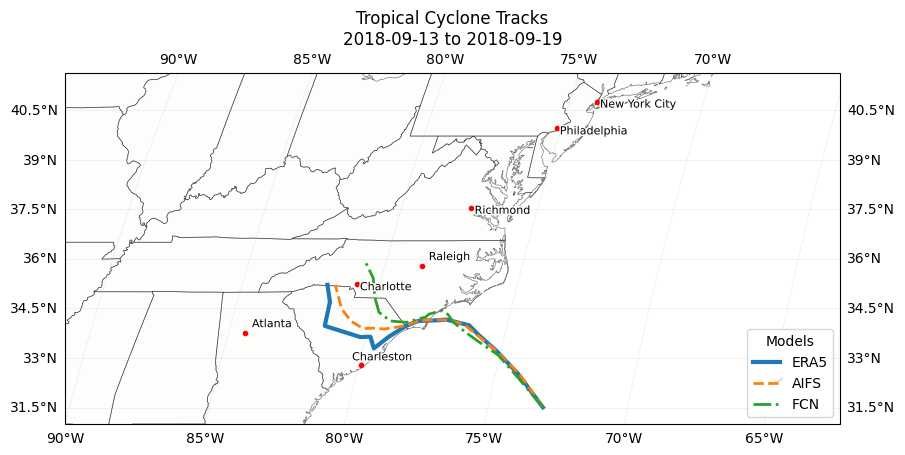

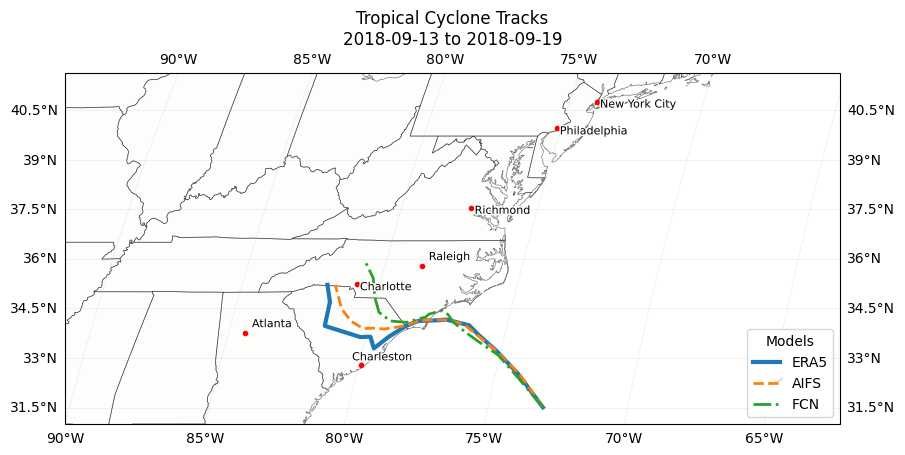

In [16]:
# Load saved tracks (or use variables from cells above)
era5_load = torch.load(FLORENCE_DIR / "era5_paths.pt", map_location="cpu")
aifs_load = torch.load(FLORENCE_DIR / "aifs_paths.pt", map_location="cpu")
fcn_load = torch.load(FLORENCE_DIR / "fcn_paths.pt", map_location="cpu")

cities = [
    ("Charlotte",    35.2271, -80.8431,  0.18, -0.18),
    ("Raleigh",      35.7796, -78.6382,  0.18,  0.18),
    ("Charleston",   32.7765, -79.9311, -0.35,  0.15),
    ("Atlanta",      33.7490, -84.3880,  0.18,  0.18),
    ("Richmond",     37.5407, -77.4360,  0.18, -0.18),
    ("Philadelphia", 39.9526, -75.1652,  0.18, -0.18),
    ("New York City", 40.7685, -73.9822,  0.18, -0.18),
]

models = [
    {"name": "ERA5",  "tracks": era5_load, "color": "#1f77b4", "lw": 3.0, "ls": "-"},
    {"name": "AIFS",  "tracks": aifs_load, "color": "#ff7f0e", "lw": 2.0, "ls": "--"},
    {"name": "FCN",   "tracks": fcn_load,  "color": "#2ca02c", "lw": 2.0, "ls": "-."},
]

plot_hurricane_tracks(
    models,
    start_time=START_TIME, end_time=END_TIME,
    extent=(-90, -65, 31, 41),
    cities=cities,
)


---
## 14-Day Extended Range Forecast: Aurora

Aurora (Microsoft, 2024) runs at 0.25° resolution with 6-hour timesteps.
Here we step it 56 times (14 days) from **January 5, 2025** — the onset of a
major polar vortex disruption — and animate the daily 500 hPa geopotential
height evolution over the Northern Hemisphere.


In [17]:
AURORA_START = "2025-01-05T00:00:00"
AURORA_STEPS = 56       # 14 days × 4 steps/day at 6h
AURORA_SAVE_EVERY = 4   # one frame per day
G = 9.80665             # m s⁻²

aurora_model = Aurora.load_model(Aurora.load_default_package())
aurora_model = aurora_model.to(DEVICE).eval()

gfs_source = GFS()
time_array = to_time_array([AURORA_START])
x, coords = fetch_data(
    source=gfs_source,
    time=time_array,
    variable=aurora_model.input_coords()["variable"],
    lead_time=aurora_model.input_coords()["lead_time"],
    device=DEVICE,
)
x, coords = map_coords(x, coords, aurora_model.input_coords())

z500_frames, frame_labels = [], []

iterator = aurora_model.create_iterator(x, coords)
for step, (x, coords) in tqdm(enumerate(iterator), total=AURORA_STEPS, desc="Aurora 14-day forecast"):
    if (step + 1) % AURORA_SAVE_EVERY == 0:
        var_list = list(coords["variable"])
        z_idx = var_list.index("z500")
        z500_frames.append(x[0, 0, z_idx].cpu().numpy())
        day = (step + 1) // AURORA_SAVE_EVERY
        valid = np.datetime64(AURORA_START) + np.timedelta64(day, "D")
        frame_labels.append(f"Day +{day}  ({str(valid)[:10]})") 
    if step + 1 >= AURORA_STEPS:
        break

print(f"Collected {len(z500_frames)} daily frames.")

del aurora_model
torch.cuda.empty_cache()

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-05-26 00:11:30.460 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 191886636-752406
2026-05-26 00:11:30.479 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 240750711-575412
2026-05-26 00:11:30.496 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 154901605-812717
2026-05-26 00:11:30.512 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 307468873-901245
2026-05-26 00:11:30.528 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 234488513-822267
2026-05-26 00:11:30.545 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

2026-05-26 00:11:30.663 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 280895168-1317255
2026-05-26 00:11:30.681 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 359090621-857328
2026-05-26 00:11:30.697 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 170899280-754777
2026-05-26 00:11:30.713 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 207941561-586515

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-05-26 00:11:30.730 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 417882300-965107
2026-05-26 00:11:31.168 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 263454569-931682
2026-05-26 00:11:31.185 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 201900730-728210
2026-05-26 00:11:31.201 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 259009093-1273217
2026-05-26 00:11:31.218 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 335224602-837932
2026-05-26 00:11:31.235 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

...

2026-05-26 00:11:33.036 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 333299075-892383
2026-05-26 00:11:33.053 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 193611512-1169521
2026-05-26 00:11:33.069 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 212614075-723296
2026-05-26 00:11:33.086 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 256579782-722504
2026-05-26 00:11:33.101 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 339966712-930628
2026-05-26 00:11:33.118 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Fetching GFS data:   0%|          | 0/69 [00:01<?, ?it/s]

2026-05-26 00:11:33.149 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 201946161-728370
2026-05-26 00:11:33.166 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 393531504-1211809
2026-05-26 00:11:33.182 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 235330348-726997
2026-05-26 00:11:33.198 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 305714296-902781
2026-05-26 00:11:33.214 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 397564488-943280
2026-05-26 00:11:33.230 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Aurora 14-day forecast:  98%|█████████▊| 55/56 [05:11<00:05,  5.67s/it]

Collected 14 daily frames.

In [17]:
AURORA_START = "2025-01-05T00:00:00"
AURORA_STEPS = 56       # 14 days × 4 steps/day at 6h
AURORA_SAVE_EVERY = 4   # one frame per day
G = 9.80665             # m s⁻²

aurora_model = Aurora.load_model(Aurora.load_default_package())
aurora_model = aurora_model.to(DEVICE).eval()

gfs_source = GFS()
time_array = to_time_array([AURORA_START])
x, coords = fetch_data(
    source=gfs_source,
    time=time_array,
    variable=aurora_model.input_coords()["variable"],
    lead_time=aurora_model.input_coords()["lead_time"],
    device=DEVICE,
)
x, coords = map_coords(x, coords, aurora_model.input_coords())

z500_frames, frame_labels = [], []

iterator = aurora_model.create_iterator(x, coords)
for step, (x, coords) in tqdm(enumerate(iterator), total=AURORA_STEPS, desc="Aurora 14-day forecast"):
    if (step + 1) % AURORA_SAVE_EVERY == 0:
        var_list = list(coords["variable"])
        z_idx = var_list.index("z500")
        z500_frames.append(x[0, 0, z_idx].cpu().numpy())
        day = (step + 1) // AURORA_SAVE_EVERY
        valid = np.datetime64(AURORA_START) + np.timedelta64(day, "D")
        frame_labels.append(f"Day +{day}  ({str(valid)[:10]})") 
    if step + 1 >= AURORA_STEPS:
        break

print(f"Collected {len(z500_frames)} daily frames.")

del aurora_model
torch.cuda.empty_cache()

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-05-26 00:11:30.460 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 191886636-752406
2026-05-26 00:11:30.479 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 240750711-575412
2026-05-26 00:11:30.496 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 154901605-812717
2026-05-26 00:11:30.512 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 307468873-901245
2026-05-26 00:11:30.528 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 234488513-822267
2026-05-26 00:11:30.545 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

2026-05-26 00:11:30.663 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 280895168-1317255
2026-05-26 00:11:30.681 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 359090621-857328
2026-05-26 00:11:30.697 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 170899280-754777
2026-05-26 00:11:30.713 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 207941561-586515

Fetching GFS data:   0%|          | 0/69 [00:00<?, ?it/s]

2026-05-26 00:11:30.730 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 417882300-965107
2026-05-26 00:11:31.168 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 263454569-931682
2026-05-26 00:11:31.185 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 201900730-728210
2026-05-26 00:11:31.201 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 259009093-1273217
2026-05-26 00:11:31.218 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250104/18/atmos/gfs.t18z.pgrb2.0p25.f000 335224602-837932
2026-05-26 00:11:31.235 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

...

2026-05-26 00:11:33.036 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 333299075-892383
2026-05-26 00:11:33.053 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 193611512-1169521
2026-05-26 00:11:33.069 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 212614075-723296
2026-05-26 00:11:33.086 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 256579782-722504
2026-05-26 00:11:33.101 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 339966712-930628
2026-05-26 00:11:33.118 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Fetching GFS data:   0%|          | 0/69 [00:01<?, ?it/s]

2026-05-26 00:11:33.149 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 201946161-728370
2026-05-26 00:11:33.166 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 393531504-1211809
2026-05-26 00:11:33.182 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 235330348-726997
2026-05-26 00:11:33.198 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 305714296-902781
2026-05-26 00:11:33.214 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250105/00/atmos/gfs.t00z.pgrb2.0p25.f000 397564488-943280
2026-05-26 00:11:33.230 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Aurora 14-day forecast:  98%|█████████▊| 55/56 [05:11<00:05,  5.67s/it]

Collected 14 daily frames.

Saved: /home/jovyan/Earth2/aurora_outputs/aurora_z500_nh_14day.gif

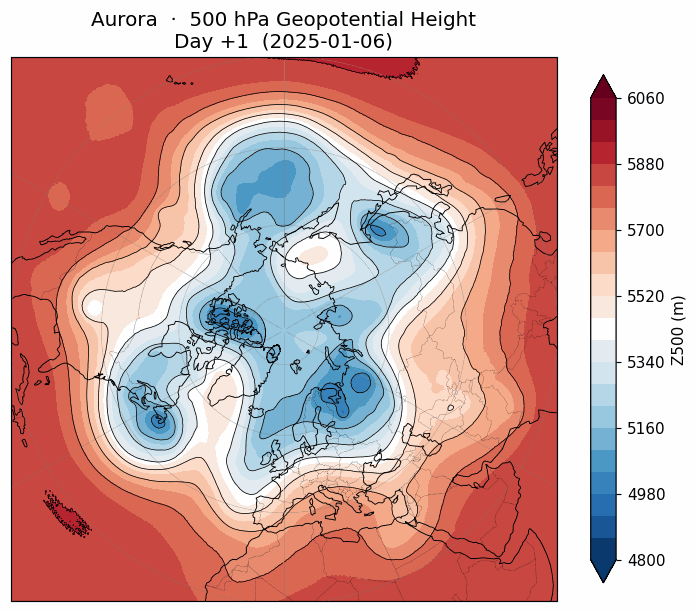

In [18]:
lats = np.asarray(coords["lat"])
lons = np.asarray(coords["lon"])

proj = ccrs.NorthPolarStereo()
frames_png = []

for z500, label in zip(z500_frames, frame_labels):
    z_height = z500 / G  # geopotential (m²/s²) → geopotential height (m)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={"projection": proj})
    ax.set_extent([-180, 180, 20, 90], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5)

    levels = np.arange(4800, 6100, 60)
    cf = ax.contourf(
        lons, lats, z_height, levels=levels,
        cmap="RdBu_r", transform=ccrs.PlateCarree(), extend="both",
    )
    ax.contour(
        lons, lats, z_height, levels=np.arange(4800, 6100, 120),
        colors="black", linewidths=0.5, transform=ccrs.PlateCarree(),
    )

    plt.colorbar(cf, ax=ax, label="Z500 (m)", shrink=0.75, pad=0.05)
    ax.set_title(f"Aurora  ·  500 hPa Geopotential Height\n{label}", fontsize=13)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    buf.seek(0)
    frames_png.append(imageio.v2.imread(buf))
    plt.close(fig)

gif_path = PROJECT_DIR / "aurora_outputs/aurora_z500_nh_14day.gif"
imageio.mimsave(str(gif_path), frames_png, fps=2, loop=0)
print(f"Saved: {gif_path}")
IPImage(str(gif_path))